# Coffee shop EDA and temporal features — Phase 2
Training dates only by default. These are synthetic sales; plots are descriptive, not causal. Historical realized weather appears only in EDA. Model weather inputs use yesterday's persistence forecast.

In [1]:
from pathlib import Path
import sys
root = next(p for p in (Path.cwd(), Path.cwd().parent) if (p / 'config/config.yaml').is_file())
sys.path.insert(0, str(root))
from src.utils.config import load_config, resolve_path
from src.eda.report import run_phase_2
from src.features.build_features import load_feature_dataset
config = load_config()
print('Python:', sys.executable)
summary = run_phase_2(config)

Python: C:\Users\aamit\OneDrive\Desktop\ProjectX\coffee-inventory-ml\.venv\Scripts\python.exe


{
  "rows": 10960,
  "predictors": 40,
  "split_counts": {
    "test": {
      "rows": 1650,
      "eligible_targets": 1593
    },
    "train": {
      "rows": 7670,
      "eligible_targets": 7326
    },
    "val": {
      "rows": 1640,
      "eligible_targets": 1562
    }
  },
  "eda": {
    "split": "train",
    "rows": 7670,
    "clean_rows": 7326,
    "start_date": "2023-01-01",
    "end_date": "2025-02-05",
    "weekly_clean_mean": {
      "0": 38.09942638623327,
      "1": 39.64957264957265,
      "2": 39.70037807183365,
      "3": 40.04381694255112,
      "4": 42.727878211227406,
      "5": 47.975190839694655,
      "6": 47.93480345158198
    },
    "festival_groups": {
      "before festival": {
        "mean": 50.964285714285715,
        "count": 196
      },
      "festival day": {
        "mean": 36.885714285714286,
        "count": 105
      },
      "ordinary": {
        "mean": 42.1423487544484,
        "count": 7025
      }
    },
    "stockout_fraction_by_item": {
     

## Weekly, festival, weather, trend and stockout patterns
Means exclude missing, censored, outlier and closure targets. Festival/weather groups can be confounded by seasonality, price and trends.

weekly


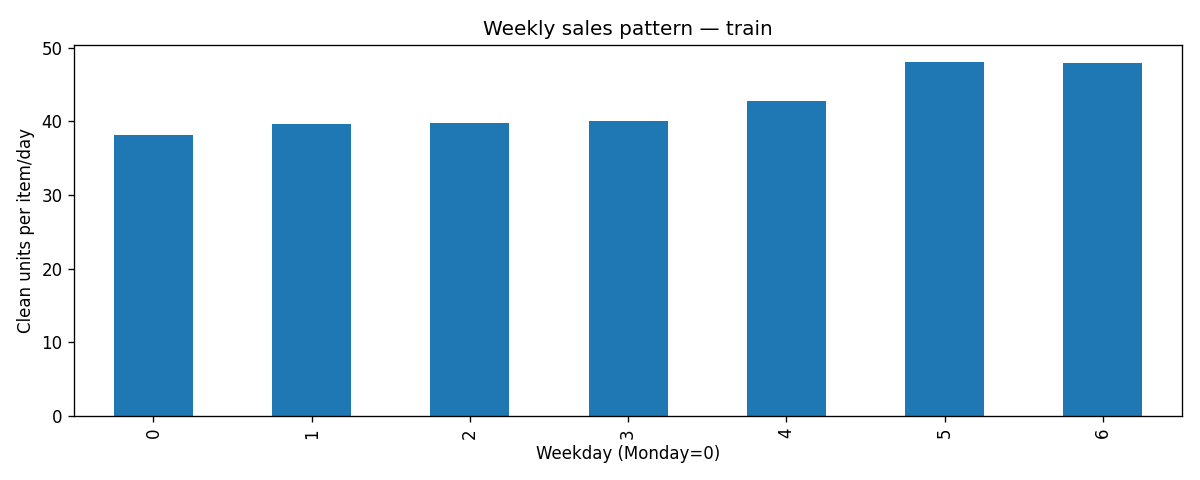

festival


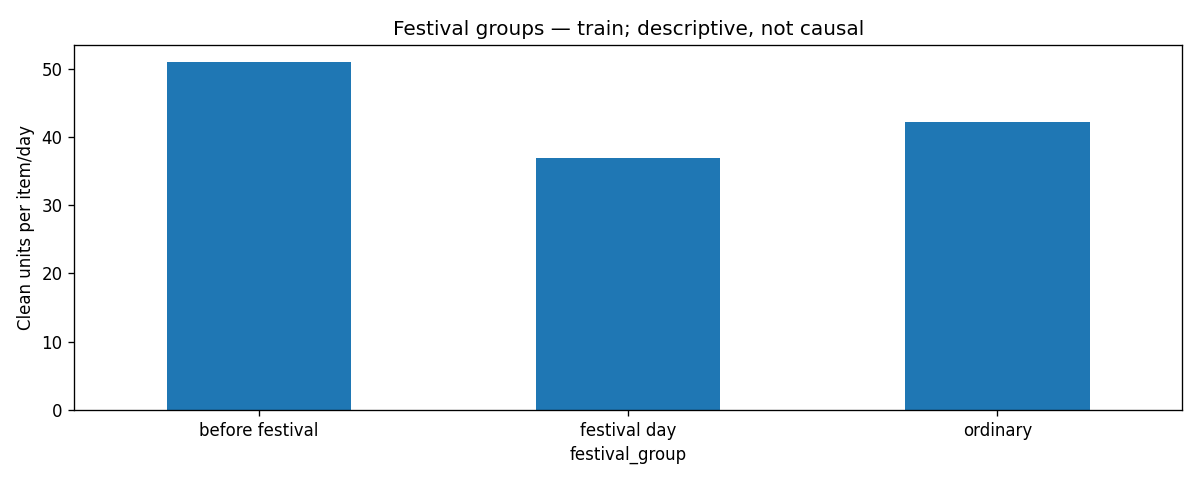

weather


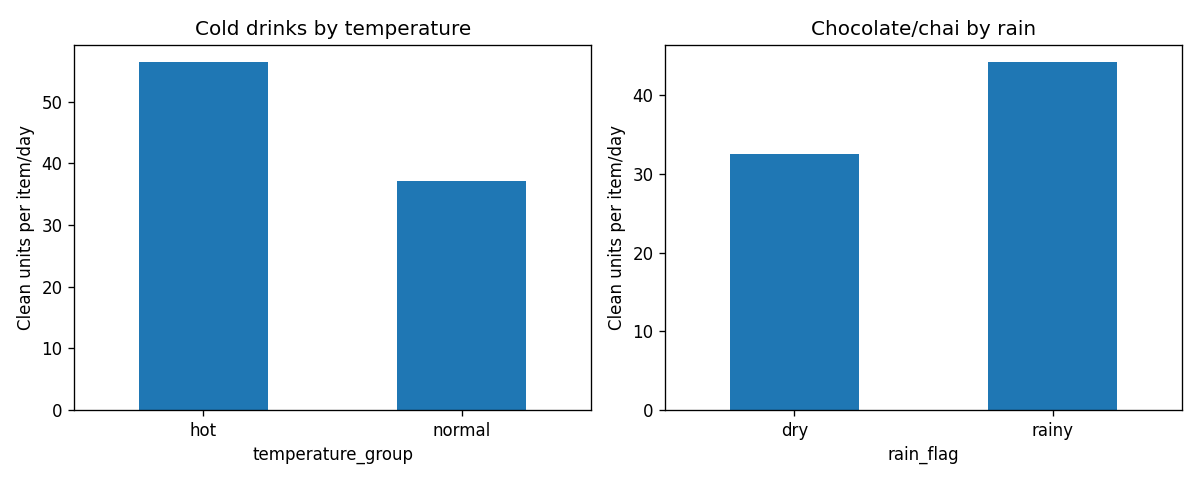

trend


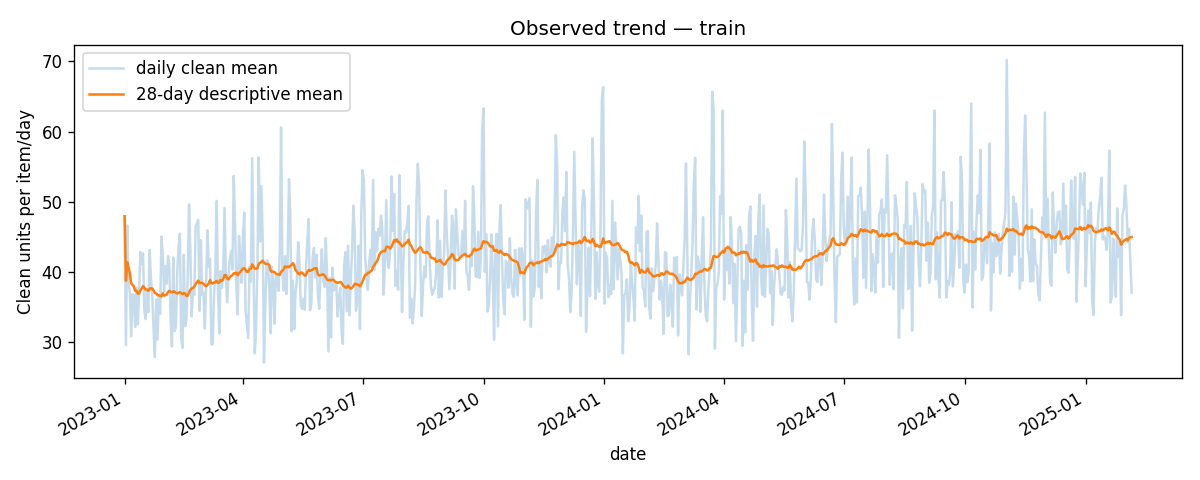

stockouts


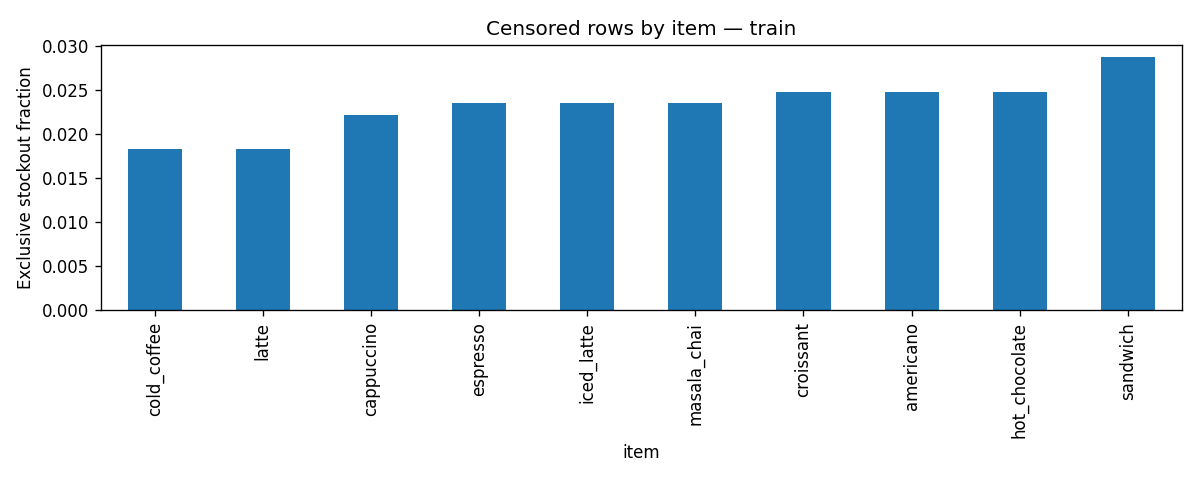

In [2]:
from IPython.display import display, Image
for name, filename in summary['eda']['figures'].items():
    print(name)
    display(Image(filename=str(resolve_path(config, 'figures') / filename)))

## Feature contract
Use only feature_columns as predictors. Target, eligibility, quality status and split are metadata. Early lags/rolling standard deviations remain missing. Preprocessing must be fitted within training folds in Phase 3.

In [3]:
dataset = load_feature_dataset(config)
print('Predictors:', len(dataset.feature_columns))
print(dataset.feature_columns)
display(dataset.frame.head(10))
print('Eligible targets by split:')
print(dataset.frame.groupby('split').target_eligible.sum())

Predictors: 40
['item', 'category', 'price', 'promo_flag', 'day_of_week', 'weekend_flag', 'day_of_month', 'week_of_year', 'month', 'month_end_flag', 'holiday_flag', 'festival_flag', 'days_to_next_festival', 'days_since_last_festival', 'payday_flag', 'long_weekend_flag', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'day_of_month_sin', 'day_of_month_cos', 'week_of_year_sin', 'week_of_year_cos', 'temp_max', 'temp_min', 'rainfall', 'rain_flag', 'temp_bucket', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'sales_rolling_mean_7', 'sales_rolling_std_7', 'sales_rolling_mean_28', 'sales_rolling_std_28', 'history_days', 'cold_start_flag', 'category_past_mean']


,date,item,category,price,promo_flag,record_status,day_of_week,weekend_flag,day_of_month,week_of_year,...,sales_rolling_std_7,sales_rolling_mean_28,sales_rolling_std_28,history_days,cold_start_flag,category_past_mean,target,target_imputed,target_eligible,split
0,2023-01-01,americano,hot_drink,110.0,0,clean,6,1,1,52,...,NaN,NaN,NaN,0,1,NaN,31.0,False,True,train
1,2023-01-01,cappuccino,hot_drink,150.0,0,clean,6,1,1,52,...,NaN,NaN,NaN,0,1,NaN,70.0,False,True,train
2,2023-01-01,cold_coffee,cold_drink,180.0,0,clean,6,1,1,52,...,NaN,NaN,NaN,0,1,NaN,46.0,False,True,train
3,2023-01-01,croissant,bakery,140.0,0,clean,6,1,1,52,...,NaN,NaN,NaN,0,1,NaN,50.0,False,True,train
4,2023-01-01,espresso,hot_drink,90.0,0,clean,6,1,1,52,...,NaN,NaN,NaN,0,1,NaN,73.0,False,True,train
5,2023-01-01,hot_chocolate,hot_drink,170.0,0,clean,6,1,1,52,...,NaN,NaN,NaN,0,1,NaN,30.0,False,True,train
6,2023-01-01,iced_latte,cold_drink,180.0,0,clean,6,1,1,52,...,NaN,NaN,NaN,0,1,NaN,40.0,False,True,train
7,2023-01-01,latte,hot_drink,160.0,0,clean,6,1,1,52,...,NaN,NaN,NaN,0,1,NaN,62.0,False,True,train
8,2023-01-01,masala_chai,hot_drink,80.0,0,clean,6,1,1,52,...,NaN,NaN,NaN,0,1,NaN,46.0,False,True,train
9,2023-01-01,sandwich,food,180.0,0,clean,6,1,1,52,...,NaN,NaN,NaN,0,1,NaN,31.0,False,True,train


Eligible targets by split:
split
test     1593
train    7326
val      1562
Name: target_eligible, dtype: int64


## Leakage demonstration
Change target-day and all future sales/weather. Predictors through that target date must stay identical. Multi-day forecasts must use the prediction interface and recursively append predictions, never future actuals.

In [4]:
import pandas as pd
from src.data.loader import load_sales
from src.features.build_features import build_features
from src.utils.dates import get_as_of_date
sales = load_sales(config)
cutoff = get_as_of_date(config)
changed = sales.copy()
changed.loc[changed.date.ge(cutoff), ['sales', 'temp_max', 'temp_min', 'rainfall']] = [999999, 999, 998, 999]
other = build_features(changed, config)
mask = dataset.frame.date.le(cutoff)
pd.testing.assert_frame_equal(dataset.frame.loc[mask, dataset.feature_columns], other.frame.loc[mask, dataset.feature_columns])
print('Current/future observation mutation: predictors through', cutoff.date(), 'unchanged — PASS')

Current/future observation mutation: predictors through 2025-07-20 unchanged — PASS


## Next phase
No forecast model was trained here. Train-only EDA shows higher weekend and pre-festival sales and lower festival-day sales. These patterns do not establish model skill. Phase 3 will compare baselines and ML with time-aware validation.